In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import h5py
import matplotlib.pyplot as plt

# Ensure local flowlot package is accessible
sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd()))

# try:
#     from FlowLOT.App.Visualization import visualization_utils as vu
# except (ModuleNotFoundError, ImportError):

import flowlot
from flowlot.App.Visualization import visualization_utils as vu


In [2]:
K_VALUES = np.arange(-1.5, 1.75, 0.75)


In [3]:
# Stage 2 HDF5 data path for BLAST110 (1000 cells)
candidates = [
    Path('../data/stage2/stage2_analytics.h5'),
    Path('data/stage2/stage2_analytics.h5')
]
STAGE2_PATH = next((p for p in candidates if p.exists()), None)
if STAGE2_PATH is None:
    raise FileNotFoundError('Could not locate stage2_analytics.h5')

print(f'Using Stage 2 dataset: {STAGE2_PATH.resolve()}')

with h5py.File(STAGE2_PATH, 'r') as h5:
    grp = h5['BLAST110']['1000']['P1']
    if 'preprocess_1' in grp and 'marker_subset' in grp['preprocess_1']:
        data_markers = grp['preprocess_1']['marker_subset'][:]
    else:
        data_markers = grp['metadata']['marker_descriptions'][:]
    marker_names = [m.decode() if isinstance(m, bytes) else m for m in data_markers]
    print(f'P1 preprocess_1 markers ({len(marker_names)}): {marker_names}')


Using Stage 2 dataset: /Volumes/g_bme-RohdeLab/Naqib/2026_AML_projects_folder/Projects/P1_FlowLOT_opencode/data/stage2/stage2_analytics.h5
P1 preprocess_1 markers (10): ['FSC-A', 'FSC-H', 'SSC-A', 'SSC-H', 'CD7', 'CD56', 'CD117', 'CD33', 'HLA-DR', 'CD45 KO']


In [4]:
import matplotlib.pyplot as plt
%matplotlib inline



Visualizing Tube: P1
Markers (10): ['FSC-A', 'FSC-H', 'SSC-A', 'SSC-H', 'CD7', 'CD56', 'CD117', 'CD33', 'HLA-DR', 'CD45 KO']


LOT embeddings loaded: X.shape=(50, 10000), Y.shape=(50,) (NBM: 20, AML_Dx: 30)
Train/Test split: Xtr.shape=(25, 10000), Xte.shape=(25, 10000)

✅ Processing tube: P1
σ∥ (train) = 1301562.5000


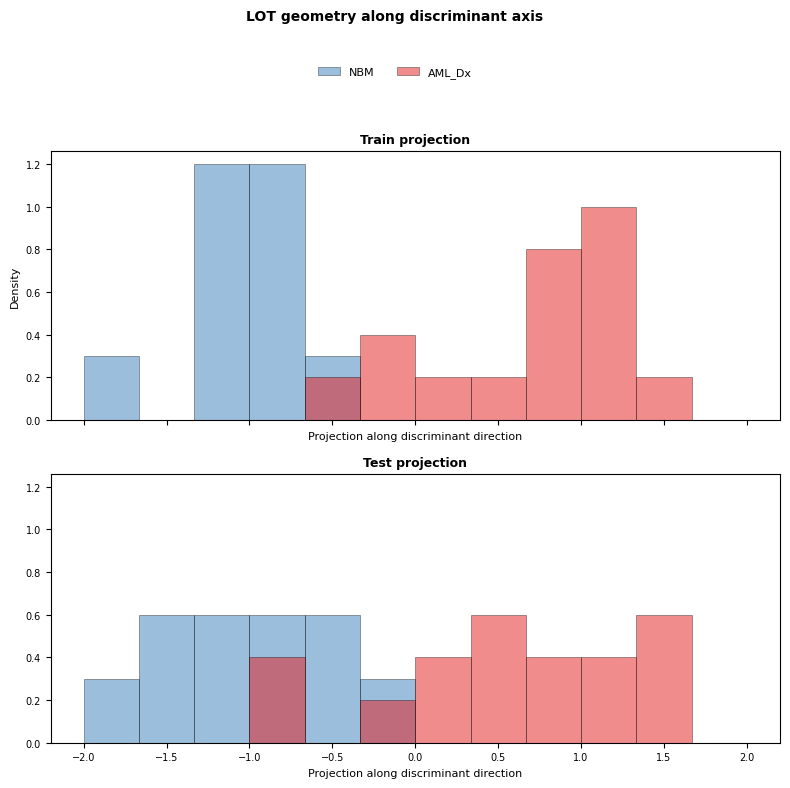


✅ Processing tube: P1
σ∥ (train) = 1301562.5000


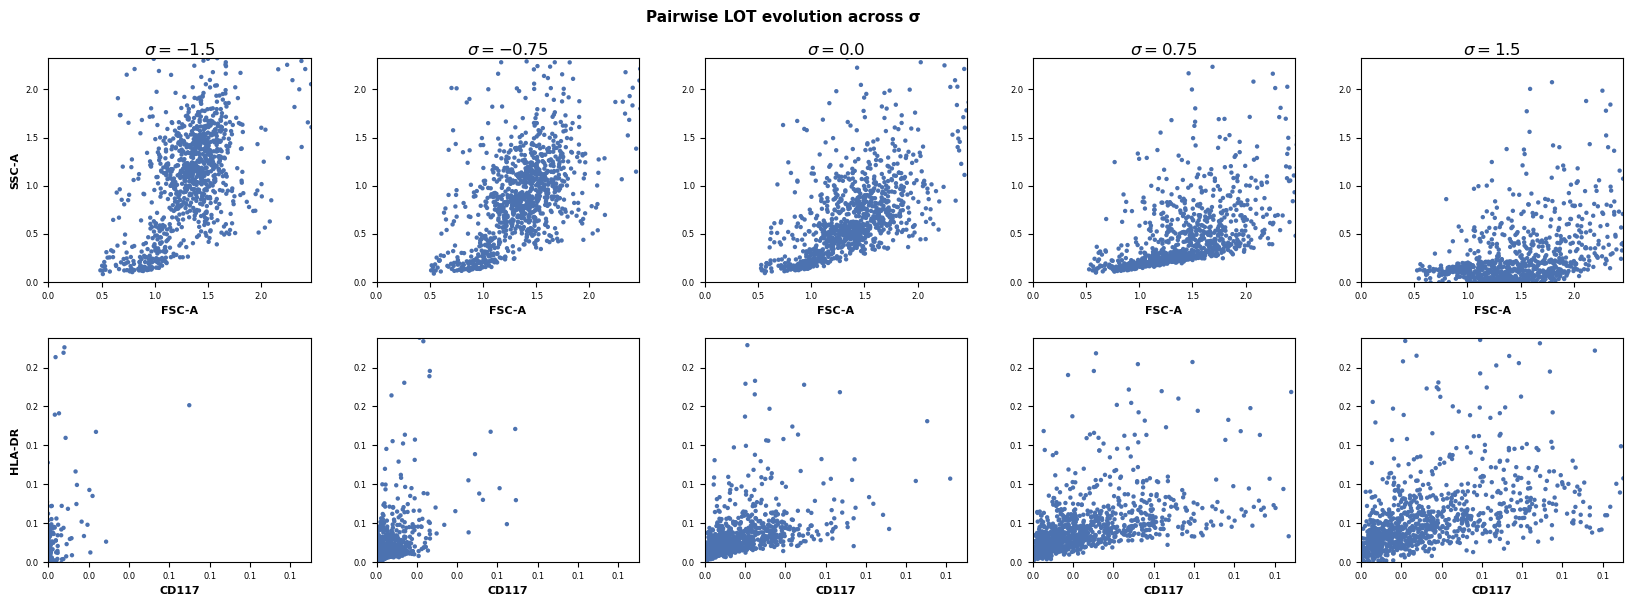


✅ Marginal plots for: P1 (palette: clinical)


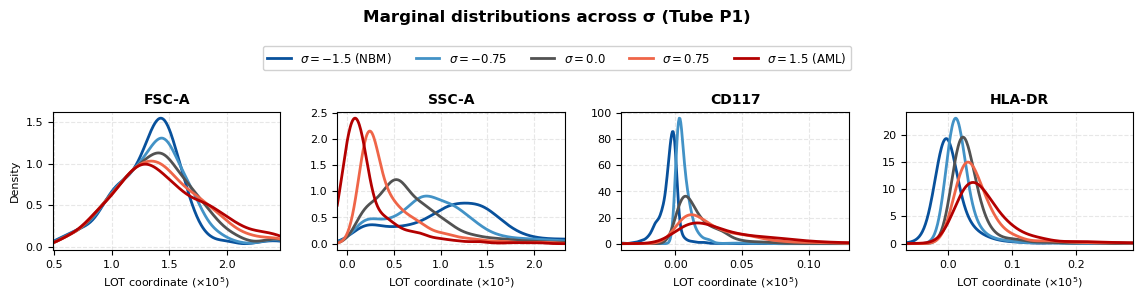

Original cell data: Xtr_org.shape=(25000, 10), Ytr_org.shape=(25000,)

✅ Plotting ORIGINAL marginals for P1


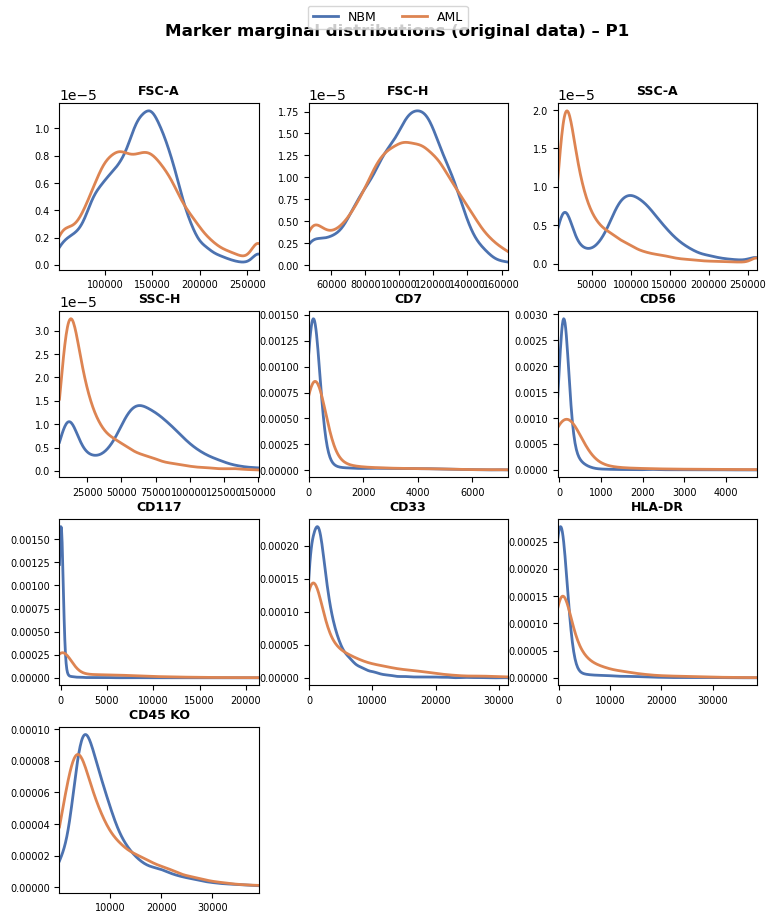

In [5]:
# Visualize BLAST110 tubes using preprocess_1 / 10-12 marker set for 1000 cells
tubes = ['P1']  # can be expanded to ['P1', 'P2', 'P3', 'P4']

for tube_name in tubes:
    print(f'\n==========================================')
    print(f'Visualizing Tube: {tube_name}')
    print(f'==========================================')
    
    # Load tube-specific marker names from preprocess_1
    marker_names = vu.get_marker_names_from_tube(
        tube_name,
        h5_data_path=str(STAGE2_PATH),
        preprocess_id='1',
        dataset_name='BLAST110',
        subsampled_cell_count='1000'
    )
    print(f'Markers ({len(marker_names)}): {marker_names}')
    
    # 1. Load LOT embeddings (patient0_emd2_map on preprocess_1 for 1000 cells)
    X, Y = vu.load_lot_by_tube(
        tube_name,
        h5_data_path=str(STAGE2_PATH),
        preprocess_id='1',
        embedding_name='patient0_emd2_map',
        dataset_name='BLAST110',
        subsampled_cell_count='1000'
    )
    print(f'LOT embeddings loaded: {X.shape=}, {Y.shape=} (NBM: {np.sum(Y == 0)}, AML_Dx: {np.sum(Y == 1)})')
    
    Xtr, Ytr, Xte, Yte = vu.stratified_split(X, Y)
    print(f'Train/Test split: {Xtr.shape=}, {Xte.shape=}')
    
    # 2. Plot 1D projection along discriminant direction
    vu.plot_lot_pairwise_evolution_nature(Xtr, Ytr, Xte, Yte, tube_name, marker_names=marker_names)
    
    # 3. Plot pairwise LOT scatter evolution across sigma values
    vu.plot_lot_pairwise_evolution_nature_final(
        Xtr, Ytr, Xte, Yte,
        tube_name,
        marker_names=marker_names,
        K_VALUES=K_VALUES,
        use_hexbin=False
    )
    
    # 4. Plot LOT marginal distributions across sigma values (corrected palette: Blue=Normal -> Red=AML)
    vu.plot_lot_marginals_all_markers(
        Xtr, Ytr, Xte, Yte,
        tube_name,
        K_VALUES=K_VALUES,
        marker_names=marker_names,
        palette='clinical'
    )
    
    # 5. Load original cell-level matrix and plot original marginal distributions
    X_org, Y_org = vu.load_org_data_by_tube(
        tube_name,
        h5_data_path=str(STAGE2_PATH),
        preprocess_id='1',
        dataset_name='BLAST110',
        subsampled_cell_count='1000'
    )
    Xtr_org, Ytr_org, Xte_org, Yte_org = vu.stratified_split(X_org, Y_org)
    print(f'Original cell data: {Xtr_org.shape=}, {Ytr_org.shape=}')
    
    vu.plot_org_marginals_by_class(
        Xtr_org,
        Ytr_org,
        marker_names,
        tube_name
    )


## 4b. Marginal Distribution Evolution with Corrected Normal-to-AML Palettes & Aesthetic Combinations

### Directional Rationale & Semantic Color Consistency
In Linear Optimal Transport (LOT), the discriminant direction vector is defined as:
$$\hat{v} = \frac{\mu_{\text{AML}} - \mu_{\text{NBM}}}{\|\mu_{\text{AML}} - \mu_{\text{NBM}}\|}

Displacing the baseline along the trajectory $x_k = \mu_{\text{all}} + k \cdot \sigma_\parallel \cdot \hat{v}$ yields:
- **Negative displacement ($k < 0$, e.g. $\sigma = -1.5$):** Moves directly into the **Normal / NBM control** density regime. In full agreement with the 1D projection histograms, this is represented by **Blue** (cool tone).
- **Zero displacement ($k = 0$, $\sigma = 0.0$):** Corresponds to the patient cohort mean baseline, represented by **Neutral Slate / Gray**.
- **Positive displacement ($k > 0$, e.g. $\sigma = +1.5$):** Moves directly into the **Leukemic blast (AML)** density regime. In full agreement with the 1D projection histograms, this is represented by **Red / Crimson** (warm tone).

### Comparison of Enhanced Color Palettes:
1. **Clinical High-Contrast Divergent (`palette='clinical'`):** Deep Navy (`#08519c`) $\rightarrow$ Sky Blue (`#4292c6`) $\rightarrow$ Slate Gray (`#525252`) $\rightarrow$ Coral (`#ef6548`) $\rightarrow$ Crimson (`#b30000`). Designed for maximum line discriminability on white publication backgrounds.
2. **Corrected Set1 Palette (`palette='set1'`):** Smooth interpolation between Set1 Blue (`#377eb8`, Normal) and Set1 Red (`#e41a1c`, AML), maintaining 1:1 color parity with the 1D projection histograms.
3. **Nature RdBu Divergent (`palette='nature_rdbu'`):** Academic standard diverging palette with darkened neutral midpoint for crystal-clear legibility.


Palette: Clinical High-Contrast Divergent (Recommended)

✅ Marginal plots for: P1 (palette: clinical)


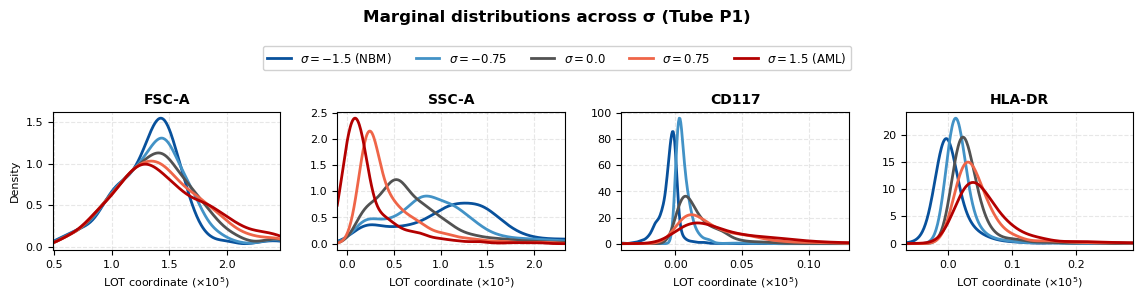


Palette: Corrected Set1 (Direct Parity with 1D Projection Histograms)

✅ Marginal plots for: P1 (palette: set1)


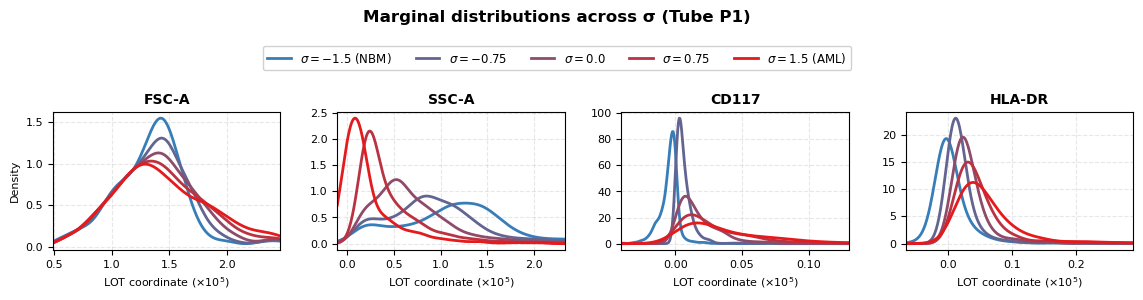


Palette: Nature RdBu Divergent

✅ Marginal plots for: P1 (palette: nature_rdbu)


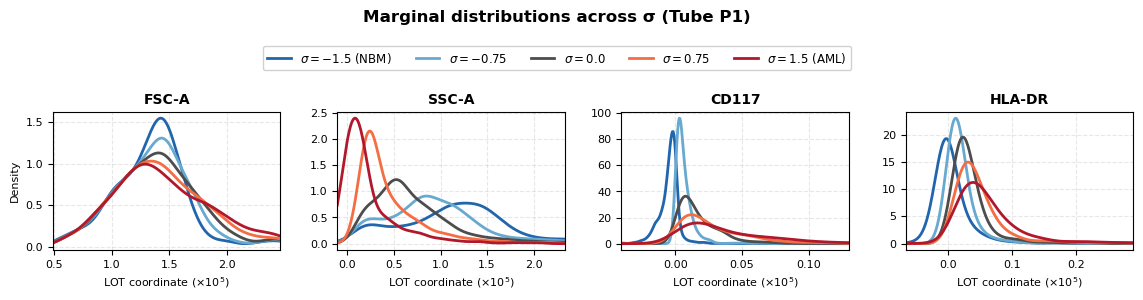

In [6]:
# Compare marginal distributions across multiple corrected & enhanced color palettes
palettes = [
    ('clinical', 'Clinical High-Contrast Divergent (Recommended)'),
    ('set1', 'Corrected Set1 (Direct Parity with 1D Projection Histograms)'),
    ('nature_rdbu', 'Nature RdBu Divergent')
]

for pal_name, pal_label in palettes:
    print(f'\n=======================================================')
    print(f'Palette: {pal_label}')
    print(f'=======================================================')
    vu.plot_lot_marginals_all_markers(
        Xtr, Ytr, Xte, Yte,
        tube_name=tube_name,
        K_VALUES=K_VALUES,
        marker_names=marker_names,
        palette=pal_name,
        save_path=f'lot_marginals_{tube_name}_{pal_name}.pdf'
    )


## 5. Composite Publication Figure 4 (Nature Medicine Style)

Generate the complete manuscript Figure 4 combining:
1. **Panel (a)**: 1D Train and Test projection histograms along the discriminant axis $\hat{v}$, with callout zoom lines and a 2×5 grid of pairwise cell-distribution projections (SSC-A vs FSC-A and CD33 vs CD34) across $\sigma \in \{-1.5, -0.75, 0.0, 0.75, 1.5\}$.
2. **Panel (b)**: 1D marginal KDE distributions across $\sigma$ for primary phenotypic blast markers, using a harmonized, colorblind-friendly divergent palette (Normal = Cool Blue, AML = Warm Red).


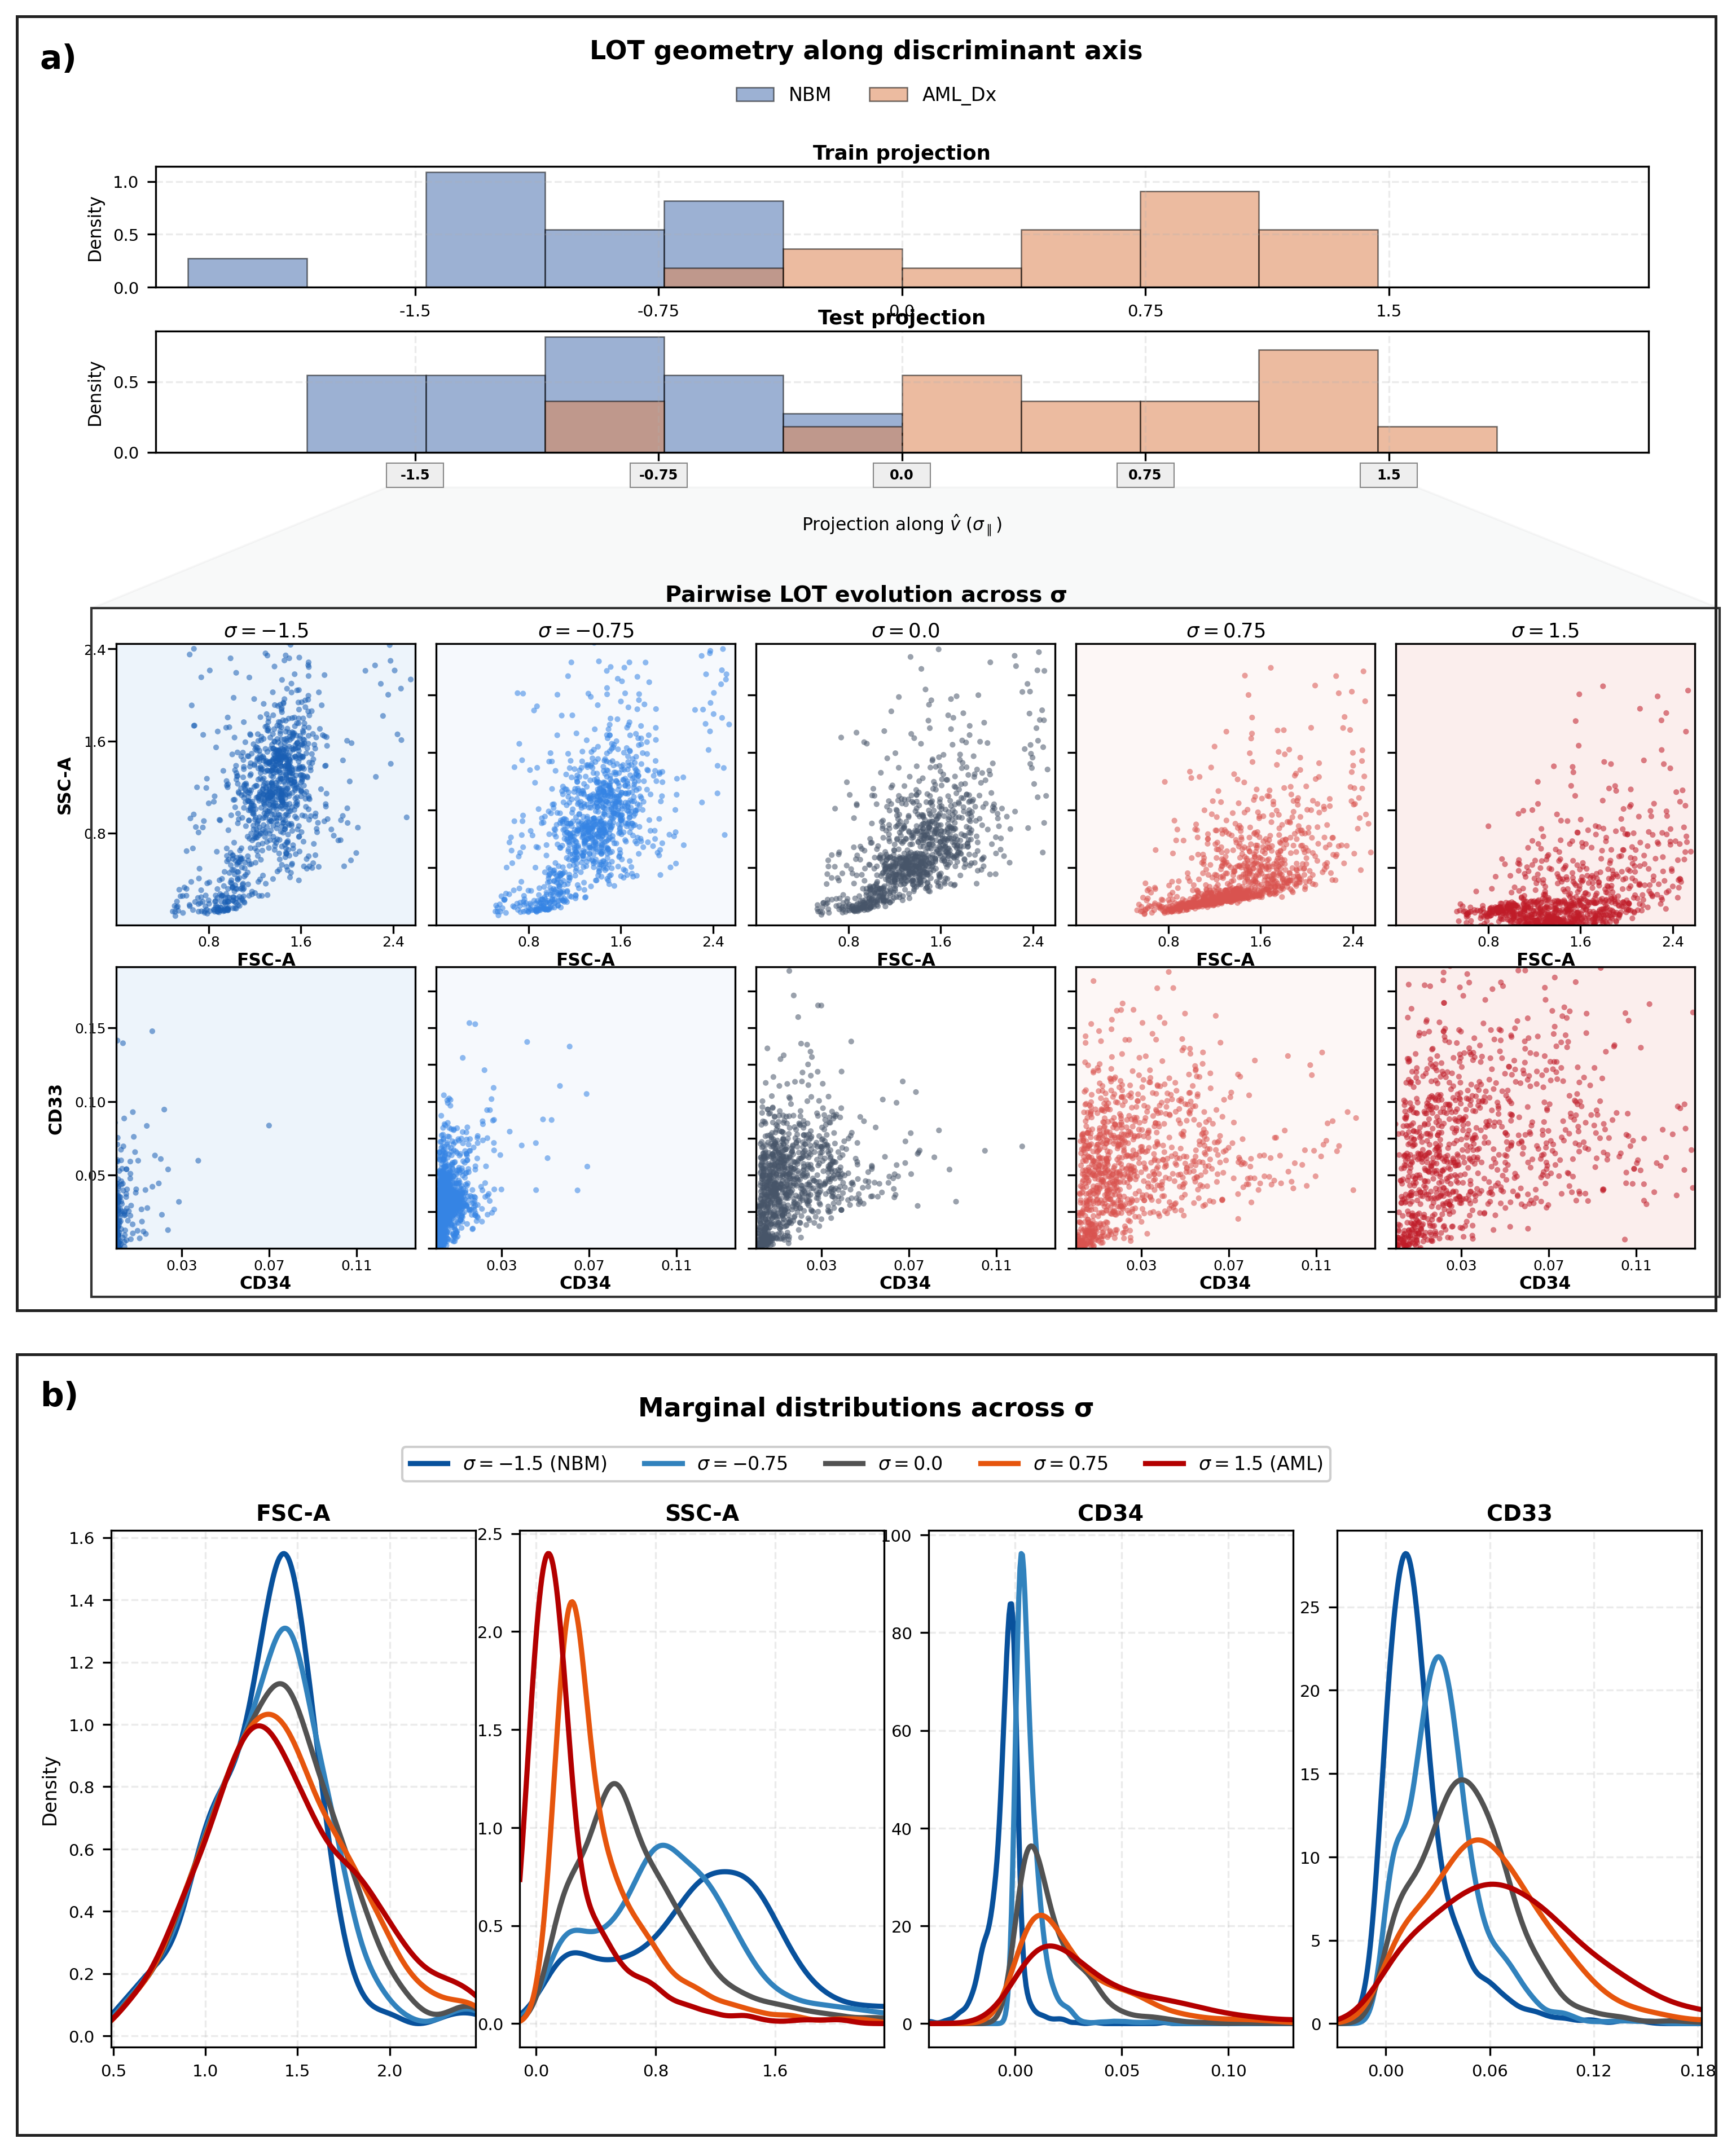

In [ ]:
# Generate and save Figure 4
fig = vu.plot_composite_figure4(
    Xtr, Ytr, Xte, Yte,
    tube_name=tube_name,
    K_VALUES=K_VALUES,
    marker_names=marker_names,
    palette='clinical',
    save_png='Figure3_Visualization.png',
    save_pdf='Figure3_Visualization.pdf',
    show=True
)
